# Laboratorio 5 - Reinforcement Learning
### José Antonio Mérida Castejón - Carné 201105

Este Notebook corresponde al Task 2 de la tarea Laboratorio 5, consiste en la implementación de un agente que navega el entorno "Frozen Lake" (tal como el lab anterior) utilizando Gymnasium y Q-Learning.

## Task 2.1 - Instalación y Ambiente
En este inciso, inicializamos el entorno utilizando Gymnasium y exploramos para conocer con lo que estaremos trabajando el resto del laboratorio. Primero, vamos a inicializar el entorno `FrozenLake-v1` con el parámetro `is_slippery=True` y `render_mode=rgb_array`.

In [104]:
import gymnasium as gym
# Cargar entorno
env = gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array")

# Inicializar entorno
env.reset()

(0, {'prob': 1})

Luego de haber cargado en entorno, podemos explorarlo un poco. Al haber trabajado un entorno similar en el laboratorio pasado, ya conocemos un poco sobre el ambiente. Vamos a empezar imprimiento el mapa, luego la cantidad de estados y acciones y por último las transiciones.

In [105]:
print("Mapa:")
print(env.unwrapped.desc)

print(f"\nEstados:  {env.observation_space.n}")
print(f"Acciones: {env.action_space.n}")

print("\nTransiciones del Estado 0:")
for action, transitions in env.unwrapped.P[0].items():
    print(f"  Acción {action}: {transitions}")

Mapa:
[[b'S' b'F' b'F' b'F']
 [b'F' b'H' b'F' b'H']
 [b'F' b'F' b'F' b'H']
 [b'H' b'F' b'F' b'G']]

Estados:  16
Acciones: 4

Transiciones del Estado 0:
  Acción 0: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 4, 0, False)]
  Acción 1: [(0.33333333333333337, 0, 0, False), (0.3333333333333333, 4, 0, False), (0.33333333333333337, 1, 0, False)]
  Acción 2: [(0.33333333333333337, 4, 0, False), (0.3333333333333333, 1, 0, False), (0.33333333333333337, 0, 0, False)]
  Acción 3: [(0.33333333333333337, 1, 0, False), (0.3333333333333333, 0, 0, False), (0.33333333333333337, 0, 0, False)]


Podemos ver que contamos con 16 estados y 4 acciones, esto es consistente con el diseño del laboratorio anterior dónde definimos una matriz de 4x4 sobre la cual navegar. Adicionalmente, las acciones son las mismas, dónde al realizar un movimiento es posible resbalarse y caer en un tile hacia la izquierda o derecha de la dirección dónde nos queremos dirigir con 1/3 de probabilidad cada uno. En cuanto al mapa, tenemos una identificación idéntica al entorno que definimos en el laboratorio pasado dónde contamos con tiles F (de Frozen), H (de Hole), S (de Start) y G (de goal). También podemos comprobar renderizar el mapa, para confirmar.

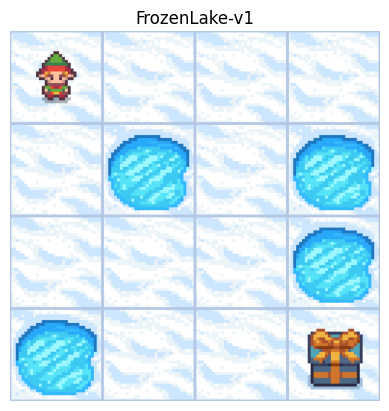

In [106]:
import matplotlib.pyplot as plt

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("FrozenLake-v1")
plt.show()

Ya con el mapa graficado, podemos concluir que el entorno ha sido cargado exitosamente y que conocemos la manera cómo funciona.

## Task 2.2- Q-Learning

Implementamos Q-Learning en una sola función que recibe los hiperparámetros y el ambiente como parámetros. Durante el entrenamiento, se sigue la política **Epsilon-Greedy** para balancear exploración y explotación, reduciendo epsilon gradualmente. Adicionalmente, permitimos que se pueda tomar Q como parámetro (default=None) para poder realizar la evaluación del Task 2.3 y también guardamos el historial de episodios.

Para la evaluación (Task 2.3), se reutiliza la misma función con `alpha=0` y `epsilon=0`, desactivando el aprendizaje y la exploración para evaluar la política aprendida de forma puramente codiciosa.

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ R + \gamma \max Q(s',a') - Q(s,a) \right]$$

In [107]:
import numpy as np

# Definición de función
def q_learning(env, alpha=0.8, Q=None, gamma=0.95, epsilon=1.0, eps_min=0.01, eps_decay=0.999, episodes=10_000):
    # Inicialización de matriz de ceros, si no es pasada como parámetro
    if Q is None:
        Q = np.zeros((env.observation_space.n, env.action_space.n))
    # Historial de episodios (reward, pasos, victoria) para análisis posterior
    history = []

    # Bucle de entrenamiento
    for ep in range(episodes):
        # Reiniciar entorno y re establecer variables
        state, _ = env.reset()
        total_reward = 0
        terminated = False
        # Pasos del episodio actual
        steps = []

        # Mientras no termine el juego
        while not terminated:
            # Elegir usando Epsilon-Greedy
            if np.random.rand() < epsilon:
                # Explorar con Epsilon de probabilidad
                action = env.action_space.sample()
            else:
                # Explotar con 1 - Epsilon de probabilidad
                action = np.argmax(Q[state])

            # Ejecutar acción y observar siguiente estado, reward y si se termina el episodio (terminated o truncated)
            next_state, reward, terminated, truncated, _ = env.step(action)
            terminated = terminated or truncated

            # Actualizar, Q(s,a) <- Q(sa) + alpha [R + gamma * max(Q(s', a') - Q(s,a)))]
            Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])

            # Actualizar estado y reward
            state = next_state
            total_reward += reward
            # Guardar paso en historial
            steps.append((state, action, next_state, reward))

        # Guardar historial del episodio y actualizar epsilon (necesario por el decay)
        history.append({"episode": ep, "reward": total_reward, "steps": steps, "won": total_reward > 0})
        epsilon = max(eps_min, epsilon * eps_decay)

    return Q, history

### Entrenamiento

In [108]:
# Entrenamiento
Q, train_history = q_learning(env)
print(f"Tasa de éxito entrenamiento (últimos 1000 ep): {np.mean([ep['won'] for ep in train_history[-1000:]]):.2%}")

Tasa de éxito entrenamiento (últimos 1000 ep): 48.30%


## Task 2.3 - Evaluación de la Política Aprendida

Con la tabla Q entrenada, evaluamos el agente en 10 episodios de prueba sin exploración (ϵ=0, puramente codicioso). Luego de estos 10 episodios, se reporta el winrate que se obtuvo. Al ser un ambiente estocástico, no podemos garantizar que tengamos el mismo output para cierto input. Entonces, para visualizar un episodio exitoso tenemos que correr un loop y visualizar el último.

Para que se pudiera visualizar en Jupyter / Github, tuve que investigar un poco y encontré [esto](https://stackoverflow.com/questions/52726475/display-openai-gym-in-jupyter-notebook-only) en Stackoverflow. Luego, utilicé IA generativa para encargarse de la parte de guardado del video. Las instrucciones fueron utilizar el esqueleto que ya se tenía para realizar runs hasta encontrar uno exitoso, dónde posteriormente se utilizara la información en Stackoverflow al igual que la documentación oficial de Gymnasium para guardarlo dentro de un GIF en gym-results. Este prompt funciona, ya que busqué una solución anteriormente (que funcionaba, para una versión vieja) y que ya contaba con un esqueleto para la lógica. También, el modelo es capaz de buscar dentro de la documentación de Gymnasium por lo cuál fue capaz de resolver este problema brevemente.

### Winrate en 10 Episodios
Aquí simplemente podemos llamar a la función que definimos anteriormente, utilizando los parámetros indicados en el laboratorio.

In [109]:
# Evaluación — misma función pero pasando Q entrenada, alpha=0 y epsilon=0 (sin aprendizaje ni exploración)
_, eval_history = q_learning(env, Q=Q, alpha=0, epsilon=0, eps_min=0, eps_decay=1, episodes=10)

# Reporte de win rate de los 10 episodios de evaluación
eval_wins = [ep for ep in eval_history if ep["won"]]
print(f"Win Rate evaluación: {len(eval_wins)}/10 ({len(eval_wins)/10:.0%})")

Win Rate evaluación: 6/10 (60%)


Podemos ver que se obtuvo un Winrate del 60%, al ser un entorno estocástico con un sample size de 10 podríamos decir que fue bastante bueno. Realmente, tendríamos que tener un sample size un poco más grande para evaluar el modelo de manera adecuada. Sin embargo, tomando en cuenta la aleatoriedad el modelo fue capaz de resolver el entorno por medio del algoritmo de Q-Learning.

### Visualización Episodio Exitoso
Aquí, como mencioné anteriormente corremos un loop hasta tener un run exitoso dónde este se guarda como un GIF.

In [ ]:
from pathlib import Path
from gymnasium.wrappers import RecordVideo
from IPython.display import Image
import imageio

# Buscar y grabar un episodio exitoso
gif_path = "./gym-results/success.gif"
for attempt in range(100):
    env_rec = RecordVideo(
        gym.make("FrozenLake-v1", is_slippery=True, render_mode="rgb_array"),
        video_folder="./gym-results",
        episode_trigger=lambda e: True
    )
    state, _ = env_rec.reset()
    terminated = False
    while not terminated:
        action = np.argmax(Q[state])
        state, reward, terminated, truncated, _ = env_rec.step(action)
        terminated = terminated or truncated
    env_rec.close()

    # Si ganó, convertir a gif y salir
    if reward == 1:
        print(f"Episodio exitoso encontrado en intento {attempt + 1}")
        mp4_path = str(sorted(Path("./gym-results").glob("*.mp4"))[-1])
        reader = imageio.get_reader(mp4_path)
        frames = [frame for frame in reader]
        imageio.mimsave(gif_path, frames, fps=reader.get_meta_data()['fps'], loop=0)
        break
else:
    print("No se encontró episodio exitoso en 100 intentos.")

Episodio exitoso encontrado en intento 1


![FrozenLake](gym-results/success.gif)

Aquí podemos ver que el algoritmo fue bastante exitoso, encontrando una win en el primer episodio. Aquí podemos ver un poco de las decisiones "raras" que toma el modelo, como dirigirse en direcciones que no lo llevarían más cerca a la meta si no fuera por los deslices. Igual al laboratorio anterior, la estrategia a seguir es toparse con la pared de la izquierda hasta bajar para poder descender de la manera más segura. Gracias a esta visualización y las estadísticas, podemos concluir que el modelo fue un éxito y el entorno está resuelto.